# P00b — CEPII Gravity Dataset

Load and explore the CEPII Gravity database (annual bilateral trade flows + controls). Convert to Arrow.

**Source:** [CEPII Gravity V202211](https://www.cepii.fr/CEPII/en/bdd_modele/bdd_modele_item.asp?id=8) — Conte, Cotterlaz & Mayer 2022. 87 columns, 1948–2020, ~252 countries, ~1.2 GB CSV.

**Purpose:** Economic nearest-neighbor edges for the trade network layer (ρ between-country). Adds the dynamic/temporal dimension that GeoDist's static edges lack.

**Key trade flow variables:**
- `tradeflow_baci` — BACI (reconciled COMTRADE), most reliable
- `tradeflow_comtrade_o/d` — raw COMTRADE (reporter/partner perspective)
- `tradeflow_imf_o/d` — IMF Direction of Trade Statistics
- `manuf_tradeflow_baci` — manufacturing trade only (BACI)

In [16]:
using DataFrames, CSV, Arrow, Statistics, ZipFile, Graphs, VegaLite

## 1. Load from Zip

~1.2 GB CSV — this will take a moment. We select only the columns we need to keep memory manageable.

In [17]:
# Columns to keep — trade flows, identifiers, key controls
KEEP_COLS = [
    # Identifiers
    :year, :iso3_o, :iso3_d, :country_id_o, :country_id_d,
    :country_exists_o, :country_exists_d,
    # Distance (already in GeoDist but useful for self-contained analysis)
    :distw_harmonic, :contig,
    # Trade flows — the core data
    :tradeflow_baci, :manuf_tradeflow_baci,
    :tradeflow_comtrade_o, :tradeflow_comtrade_d,
    :tradeflow_imf_o, :tradeflow_imf_d,
    # Economic size (for normalization context)
    :gdp_o, :gdp_d, :pop_o, :pop_d,
    # Institutional/trade agreements
    :gatt_o, :gatt_d, :wto_o, :wto_d,
    :eu_o, :eu_d, :fta_wto,
    # Colonial/cultural (supplements GeoDist)
    :comrelig, :col_dep_ever, :sibling_ever, :empire,
    :diplo_disagreement, :scaled_sci_2021
]

@time begin
    # Read from zip
    zf = ZipFile.Reader("data/Gravity_csv_V202211.zip")
    gravity_entry = first(filter(f -> endswith(f.name, "Gravity_V202211.csv"), zf.files))
    raw = CSV.read(gravity_entry, DataFrame; select=KEEP_COLS)
    close(zf)
    println("Loaded: $(nrow(raw)) rows × $(ncol(raw)) cols")
end

Loaded: 4699296 rows × 32 cols
 30.920422 seconds (35.58 M allocations: 9.997 GiB, 3.82% gc time, 0.03% compilation time)


In [18]:
describe(raw)

Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Union…,Any,Union…,Any,Int64,Type
1,year,1984.5,1948,1984.5,2021,0,Int64
2,country_id_o,,ABW,,ZWE,0,String7
3,country_id_d,,ABW,,ZWE,0,String7
4,iso3_o,,ABW,,ZWE,0,String3
5,iso3_d,,ABW,,ZWE,0,String3
6,country_exists_o,0.877628,0,1.0,1,0,Int64
7,country_exists_d,0.877628,0,1.0,1,0,Int64
8,distw_harmonic,8602.49,0,8223.0,19904,1071452,"Union{Missing, Int64}"
9,contig,0.0117593,0,0.0,1,1071452,"Union{Missing, Int64}"


In [19]:
first(raw, 5)

Row,year,country_id_o,country_id_d,iso3_o,iso3_d,country_exists_o,country_exists_d,distw_harmonic,contig,diplo_disagreement,scaled_sci_2021,comrelig,col_dep_ever,empire,sibling_ever,pop_o,pop_d,gdp_o,gdp_d,gatt_o,gatt_d,wto_o,wto_d,eu_o,eu_d,fta_wto,tradeflow_comtrade_o,tradeflow_comtrade_d,tradeflow_baci,manuf_tradeflow_baci,tradeflow_imf_o,tradeflow_imf_d
,Int64,String7,String7,String3,String3,Int64,Int64,Int64?,Int64?,Float64?,Float64?,Float64?,Int64?,String3?,Int64?,Float64?,Float64?,Float64?,Float64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?
1,1948,ABW,ABW,ABW,ABW,0,0,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing
2,1949,ABW,ABW,ABW,ABW,0,0,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing
3,1950,ABW,ABW,ABW,ABW,0,0,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing
4,1951,ABW,ABW,ABW,ABW,0,0,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing
5,1952,ABW,ABW,ABW,ABW,0,0,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing


## 2. Remap, Temporal Floor, Write Arrow

Apply ISO3 remapping and temporal floor, then write to Arrow. All further analysis loads from Arrow.

In [20]:
# ISO3 remapping (same as GeoDist)
const GRAVITY_ISO3_REMAP = Dict("ROM" => "ROU", "ZAR" => "COD", "TMP" => "TLS")

function remap_iso3!(df::DataFrame, col::Symbol)
    df[!, col] = [ismissing(v) ? missing : get(GRAVITY_ISO3_REMAP, String(v), String(v)) for v in df[!, col]]
    return df
end

remap_iso3!(raw, :iso3_o)
remap_iso3!(raw, :iso3_d)
remap_iso3!(gravity_countries, :iso3)

# Temporal floor
include("constants.jl")
gravity = filter(r -> r.year >= TEMPORAL_FLOOR, raw)
println("Before floor: $(nrow(raw)) rows ($(minimum(raw.year))–$(maximum(raw.year)))")
println("After floor:  $(nrow(gravity)) rows ($(TEMPORAL_FLOOR)–$(maximum(gravity.year)))")
println("Dropped:      $(nrow(raw) - nrow(gravity)) rows")

# String conversion for Arrow
for col in names(gravity)
    if nonmissingtype(eltype(gravity[!, col])) <: AbstractString
        gravity[!, col] = passmissing(String).(gravity[!, col])
    end
end
for col in names(gravity_countries)
    if nonmissingtype(eltype(gravity_countries[!, col])) <: AbstractString
        gravity_countries[!, col] = passmissing(String).(gravity_countries[!, col])
    end
end

# Write
Arrow.write("data/cepii_gravity.arrow", gravity)
println("\n  → data/cepii_gravity.arrow  ($(round(filesize("data/cepii_gravity.arrow") / 1024^2, digits=1)) MB)")
Arrow.write("data/cepii_gravity_countries.arrow", gravity_countries)
println("  → data/cepii_gravity_countries.arrow  ($(round(filesize("data/cepii_gravity_countries.arrow") / 1024, digits=1)) KB)")

Before floor: 4699296 rows (1948–2021)
After floor:  4572288 rows (1950–2021)
Dropped:      127008 rows

  → data/cepii_gravity.arrow  (1096.5 MB)
  → data/cepii_gravity_countries.arrow  (29.3 KB)


## 3. Missingness Analysis (from Arrow)

Free up CSV memory — reload from Arrow and analyze what's missing.

In [21]:
# Free CSV memory, reload from Arrow
raw = nothing; GC.gc()
grav = DataFrame(Arrow.Table("data/cepii_gravity.arrow"))
println("Loaded from Arrow: $(nrow(grav)) rows × $(ncol(grav)) cols")

Loaded from Arrow: 4572288 rows × 32 cols


### 3b. Countries Lookup and QoG Alignment

In [27]:
# Load Countries lookup from the same zip
zf = ZipFile.Reader("data/Gravity_csv_V202211.zip")
countries_entry = first(filter(f -> endswith(f.name, "Countries_V202211.csv"), zf.files))
gravity_countries = CSV.read(countries_entry, DataFrame)
close(zf)

println("$(nrow(gravity_countries)) countries × $(ncol(gravity_countries)) cols")
describe(gravity_countries)

252 countries × 12 cols


Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Union…,Any,Union…,Any,Int64,Type
1,country_id,,ABW,,ZWE,0,String7
2,iso3,,ABW,,ZWE,0,String3
3,iso3num,438.108,4,440.0,894,1,"Union{Missing, Int64}"
4,country,,Afghanistan,,Zimbabwe,0,String
5,countrylong,,American Samoa,,Yemen Arab Republic,0,String
6,first_year,1988.65,1949,1991.0,2011,209,"Union{Missing, Int64}"
7,last_year,1989.59,1964,1990.0,2010,235,"Union{Missing, Int64}"
8,countrygroup_iso3,,ANT,,YUG,197,"Union{Missing, String3}"
9,countrygroup_iso3num,645.855,200,736.0,891,197,"Union{Missing, Int64}"


In [28]:
# Key fields: existence dates, country groups, hegemonic power
# Note: last_year=missing means the country still exists
println("Existence spans:")
println("  Earliest first_year: $(minimum(skipmissing(gravity_countries.first_year)))")
println("  Historical (last_year set): $(count(!ismissing, gravity_countries.last_year))")
println("  Currently existing (last_year missing): $(count(ismissing, gravity_countries.last_year))")
println()

# Historical entities — dissolved states
historical = filter(r -> !ismissing(r.last_year), gravity_countries)
println("Historical entities ($(nrow(historical))):")
for r in eachrow(sort(historical, :last_year))
    println("  $(rpad(String(r.iso3), 5)) $(rpad(r.country, 35)) $(r.first_year)-$(r.last_year)")
end
println()

# Country groups — territories grouped under sovereigns
grouped = filter(r -> !ismissing(r.countrygroup_iso3) && r.iso3 != r.countrygroup_iso3, gravity_countries)
println("Territories grouped under a sovereign: $(nrow(grouped))")
first(select(grouped, :iso3, :country, :countrygroup_iso3, :first_year, :last_year), 10)

Existence spans:
  Earliest first_year: 1949
  Historical (last_year set): 17
  Currently existing (last_year missing): 235

Historical entities (17):
  MYS   Malaysia + Singapore                missing-1964
  PAK   Pakistan + Bangladesh               missing-1970
  VNM   South Vietnam                       missing-1975
  VDR   North Vietnam                       1954-1976
  ANT   Netherlands Antilles + Aruba        missing-1985
  DEU   West Germany                        missing-1989
  YEM   North Yemen                         missing-1989
  DDR   East Germany                        1949-1990
  YMD   South Yemen                         1967-1990
  SUN   USSR                                missing-1991
  ETH   Ethiopia + Eritrea                  missing-1992
  YUG   Yugoslavia                          missing-1992
  CSK   Czechoslovakia                      missing-1993
  IDN   Indonesia + Timor-Leste             missing-2001
  SCG   Serbia and Montenegro               1992-2006
  SDN 

Row,iso3,country,countrygroup_iso3,first_year,last_year
,String3,String,String3?,Int64?,Int64?
1,ARM,Armenia,SUN,1991,missing
2,ABW,Aruba,ANT,1986,missing
3,AZE,Azerbaijan,SUN,1991,missing
4,BGD,Bangladesh,PAK,1971,missing
5,BLR,Belarus,SUN,1991,missing
6,BIH,Bosnia and Herzegovina,YUG,1992,missing
7,HRV,Croatia,YUG,1991,missing
8,CZE,Czech Republic,CSK,1993,missing
9,DDR,East Germany,DEU,1949,1990


In [29]:
# Hegemonic power assignments — sphere of influence
heg = filter(r -> !ismissing(r.heg_iso3_2020), gravity_countries)
heg_counts = combine(groupby(heg, :heg_iso3_2020), nrow => :n_countries)
sort!(heg_counts, :n_countries, rev=true)
println("Hegemonic power spheres (2020):")
heg_counts

Hegemonic power spheres (2020):


Row,heg_iso3_2020,n_countries
,String3?,Int64
1,GBR,11
2,FRA,9
3,USA,4
4,NLD,4
5,AUS,3
6,NZL,3
7,CHN,3
8,DNK,2
9,MAR,1


In [30]:
# Load QoG for alignment check
qog = DataFrame(Arrow.Table("data/qog_std_ts_jan25_aug.arrow"))
qog_codes_set = Set(unique(skipmissing(qog.ident_ccodealp)))

# Cross-reference with QoG — how well does the Gravity countries list align?
qog_codes_set = Set(unique(skipmissing(qog.ident_ccodealp)))
grav_country_codes = Set(unique(skipmissing(gravity_countries.iso3)))

# Currently existing countries in Gravity that are also in QoG
current_grav = filter(r -> ismissing(r.last_year), gravity_countries)
current_codes = Set(String.(current_grav.iso3))
overlap_current = intersect(current_codes, qog_codes_set)

println("Gravity countries (current, 2020): $(length(current_codes))")
println("QoG countries: $(length(qog_codes_set))")
println("Overlap (current Gravity ∩ QoG): $(length(overlap_current))")
println()

# Could this serve as a master country list?
in_qog_not_grav = sort(collect(setdiff(qog_codes_set, current_codes)))
in_grav_not_qog = sort(collect(setdiff(current_codes, qog_codes_set)))
println("In QoG but not current Gravity ($(length(in_qog_not_grav))):")
for c in in_qog_not_grav
    println("  $c")
end
println()
println("In current Gravity but not QoG ($(length(in_grav_not_qog))):")
for c in in_grav_not_qog
    println("  $c")
end

Gravity countries (current, 2020): 235
QoG countries: 202
Overlap (current Gravity ∩ QoG): 194

In QoG but not current Gravity (8):
  CSK
  DDR
  SCG
  SUN
  VDR
  XTI
  YMD
  YUG

In current Gravity but not QoG (41):
  ABW
  AIA
  ASM
  BES
  BMU
  CCK
  COK
  CUW
  CXR
  CYM
  ESH
  FLK
  FRO
  GIB
  GLP
  GRL
  GUF
  GUM
  HKG
  IOT
  MAC
  MNP
  MSR
  MTQ
  MYT
  NCL
  NFK
  NIU
  PCN
  PRI
  PSE
  PYF
  REU
  SHN
  SPM
  SXM
  TCA
  TKL
  VAT
  VGB
  WLF


In [31]:
# Overall missingness — sorted worst to best
miss_df = DataFrame(
    column = String[],
    n_missing = Int[],
    pct_missing = Float64[],
    pre1990_miss = Float64[],
    post1990_miss = Float64[]
)

pre = filter(r -> r.year < 1990, grav)
post = filter(r -> r.year >= 1990, grav)

for col in names(grav)
    n_miss = count(ismissing, grav[!, col])
    pct = round(100 * n_miss / nrow(grav), digits=1)
    pre_pct = nrow(pre) > 0 ? round(100 * count(ismissing, pre[!, col]) / nrow(pre), digits=1) : 0.0
    post_pct = nrow(post) > 0 ? round(100 * count(ismissing, post[!, col]) / nrow(post), digits=1) : 0.0
    push!(miss_df, (column=String(col), n_missing=n_miss, pct_missing=pct, pre1990_miss=pre_pct, post1990_miss=post_pct))
end

sort!(miss_df, :pct_missing, rev=true)
println("Missingness by column (worst first):")
println("─"^90)
miss_df

Missingness by column (worst first):
──────────────────────────────────────────────────────────────────────────────────────────


Row,column,n_missing,pct_missing,pre1990_miss,post1990_miss
,String,Int64,Float64,Float64,Float64
1,tradeflow_baci,3877460,84.8,100.0,65.8
2,manuf_tradeflow_baci,3877460,84.8,100.0,65.8
3,tradeflow_comtrade_o,3726747,81.5,90.1,70.7
4,tradeflow_imf_o,3663646,80.1,89.5,68.4
5,tradeflow_comtrade_d,3606450,78.9,89.0,66.2
6,tradeflow_imf_d,3575836,78.2,88.7,65.1
7,diplo_disagreement,2941148,64.3,77.4,48.0
8,scaled_sci_2021,2620835,57.3,63.3,49.8
9,comrelig,1937582,42.4,47.4,36.1


In [34]:
# Structural missingness: countries that report NO trade with ANY partner in a year
println("Countries with zero trade data for ALL partners (by year):")
println("─"^70)
for yr in [1960, 1970, 1980, 1990, 2000, 2010, 2019]
    yr_data = filter(r -> r.year == yr, grav)
    nrow(yr_data) == 0 && continue
    country_coverage = combine(groupby(yr_data, :iso3_o),
        :tradeflow_baci => (x -> count(!ismissing, x)) => :n_baci,
        :tradeflow_imf_o => (x -> count(!ismissing, x)) => :n_imf,
        nrow => :n_pairs
    )
    no_baci = count(==(0), country_coverage.n_baci)
    no_imf = count(==(0), country_coverage.n_imf)
    total = nrow(country_coverage)
    println("  $yr: $total countries, $no_baci with no BACI, $no_imf with no IMF")
end

Countries with zero trade data for ALL partners (by year):
──────────────────────────────────────────────────────────────────────
  1960: 243 countries, 243 with no BACI, 144 with no IMF
  1970: 243 countries, 243 with no BACI, 113 with no IMF
  1980: 243 countries, 243 with no BACI, 114 with no IMF
  1990: 243 countries, 243 with no BACI, 86 with no IMF
  2000: 243 countries, 23 with no BACI, 41 with no IMF
  2010: 243 countries, 20 with no BACI, 37 with no IMF
  2019: 243 countries, 19 with no BACI, 37 with no IMF


In [35]:
# Who are the 2019 BACI non-reporters? Are they in our QoG country set?
yr2019 = filter(r -> r.year == 2019, grav)
cov2019 = combine(groupby(yr2019, :iso3_o),
    :tradeflow_baci => (x -> count(!ismissing, x)) => :n_baci
)
no_baci_2019 = filter(r -> r.n_baci == 0, cov2019)
sort!(no_baci_2019, :iso3_o)

in_qog = count(c -> c in qog_codes_set, no_baci_2019.iso3_o)
println("2019 BACI non-reporters: $(nrow(no_baci_2019)) ($(in_qog) are in QoG)")
for c in no_baci_2019.iso3_o
    flag = c in qog_codes_set ? " ← QoG" : ""
    println("  $c$flag")
end


2019 BACI non-reporters: 19 (9 are in QoG)
  ANT
  CSK ← QoG
  DDR ← QoG
  ESH
  FRO
  GLP
  GUF
  LIE ← QoG
  MCO ← QoG
  MTQ
  MYT
  PRI
  REU
  SCG ← QoG
  SUN ← QoG
  VAT
  VDR ← QoG
  YMD ← QoG
  YUG ← QoG


In [36]:
# Trade flow coverage by decade — which source is best in each era?
trade_cols = [:tradeflow_baci, :manuf_tradeflow_baci, :tradeflow_comtrade_o, :tradeflow_comtrade_d, :tradeflow_imf_o, :tradeflow_imf_d]

println("Trade flow completeness by decade (% of pairs with data):")
println("─"^110)
println("  $(rpad("Decade", 12)) $(join([rpad(string(c), 16) for c in trade_cols]))")
println("─"^110)
for decade in [1950, 1960, 1970, 1980, 1990, 2000, 2010]
    dec = filter(r -> r.year >= decade && r.year < decade + 10, grav)
    if nrow(dec) == 0 continue end
    parts = String[]
    for col in trade_cols
        pct = round(100 * count(!ismissing, dec[!, col]) / nrow(dec), digits=0)
        push!(parts, rpad("$(Int(pct))%", 16))
    end
    println("  $(rpad("$(decade)s", 12)) $(join(parts))")
end

Trade flow completeness by decade (% of pairs with data):
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
  Decade       tradeflow_baci  manuf_tradeflow_bacitradeflow_comtrade_otradeflow_comtrade_dtradeflow_imf_o tradeflow_imf_d 
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
  1950s        0%              0%              0%              0%              5%              5%              
  1960s        0%              0%              8%              9%              8%              9%              
  1970s        0%              0%              15%             17%             12%             14%             
  1980s        0%              0%              16%             18%             17%             18%             
  1990s        11%             11%             22%             24%             24%             25%             
  2000s        44%             44%  

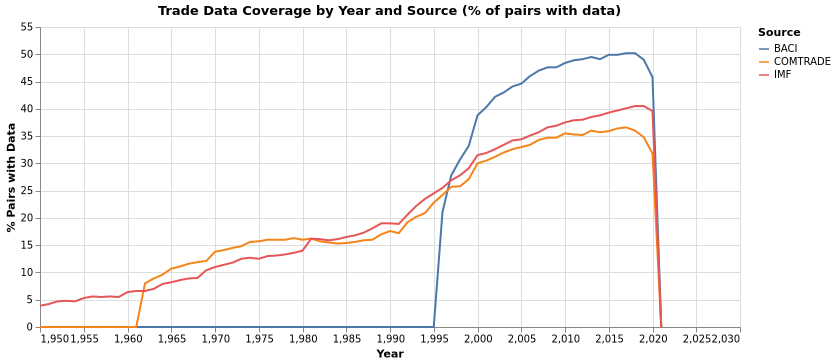

In [37]:
# Visualize trade coverage over time
year_coverage = combine(groupby(grav, :year),
    nrow => :n_pairs,
    :tradeflow_baci => (x -> round(100 * count(!ismissing, x) / length(x), digits=1)) => :baci_pct,
    :tradeflow_comtrade_o => (x -> round(100 * count(!ismissing, x) / length(x), digits=1)) => :comtrade_pct,
    :tradeflow_imf_o => (x -> round(100 * count(!ismissing, x) / length(x), digits=1)) => :imf_pct
)
sort!(year_coverage, :year)

# Reshape for VegaLite
cov_long = vcat(
    DataFrame(year=year_coverage.year, pct=year_coverage.baci_pct, source=fill("BACI", nrow(year_coverage))),
    DataFrame(year=year_coverage.year, pct=year_coverage.comtrade_pct, source=fill("COMTRADE", nrow(year_coverage))),
    DataFrame(year=year_coverage.year, pct=year_coverage.imf_pct, source=fill("IMF", nrow(year_coverage)))
)

cov_long |> @vlplot(
    width=700, height=300,
    title="Trade Data Coverage by Year and Source (% of pairs with data)",
    mark={:line, strokeWidth=2},
    x={field=:year, type=:quantitative, title="Year"},
    y={field=:pct, type=:quantitative, title="% Pairs with Data"},
    color={field=:source, type=:nominal, title="Source"}
)

## 4. Trade Network Connectivity

Build annual trade graphs from BACI flow data. How has the global trade network evolved?

In [38]:
# Build trade network stats per year using BACI
grav_codes_set = Set(unique(skipmissing(grav.iso3_o)))
qog_matched = intersect(grav_codes_set, qog_codes_set)

network_stats = DataFrame(
    year=Int[], n_nodes=Int[], n_edges=Int[], density=Float64[],
    mean_degree=Float64[], max_degree=Int[], n_components=Int[],
    total_trade=Float64[]
)

for yr in sort(unique(grav.year))
    yr_data = filter(r -> r.year == yr && 
                          !ismissing(r.tradeflow_baci) && r.tradeflow_baci > 0 &&
                          !ismissing(r.iso3_o) && !ismissing(r.iso3_d) &&
                          r.iso3_o in qog_matched && r.iso3_d in qog_matched &&
                          r.iso3_o != r.iso3_d,
                    grav)
    
    nrow(yr_data) == 0 && continue
    
    countries = sort(unique(vcat(yr_data.iso3_o, yr_data.iso3_d)))
    idx = Dict(c => i for (i, c) in enumerate(countries))
    g = SimpleGraph(length(countries))
    for r in eachrow(yr_data)
        add_edge!(g, idx[r.iso3_o], idx[r.iso3_d])
    end
    
    degs = degree(g)
    push!(network_stats, (
        year=yr, n_nodes=nv(g), n_edges=ne(g),
        density=nv(g) > 1 ? 2 * ne(g) / (nv(g) * (nv(g) - 1)) : 0.0,
        mean_degree=mean(degs), max_degree=maximum(degs),
        n_components=length(connected_components(g)),
        total_trade=sum(yr_data.tradeflow_baci)
    ))
end

println("Network stats for $(nrow(network_stats)) years")
first(network_stats, 5)

Network stats for 25 years


Row,year,n_nodes,n_edges,density,mean_degree,max_degree,n_components,total_trade
,Int64,Int64,Int64,Float64,Float64,Int64,Int64,Float64
1,1996,183,6469,0.388459,70.6995,182,1,4.68541e9
2,1997,183,8873,0.532817,96.9727,182,1,5.09546e9
3,1998,183,9796,0.588242,107.06,182,1,5.09047e9
4,1999,184,10602,0.629722,115.239,183,1,5.34435e9
5,2000,189,12274,0.69087,129.884,188,1,6.05135e9


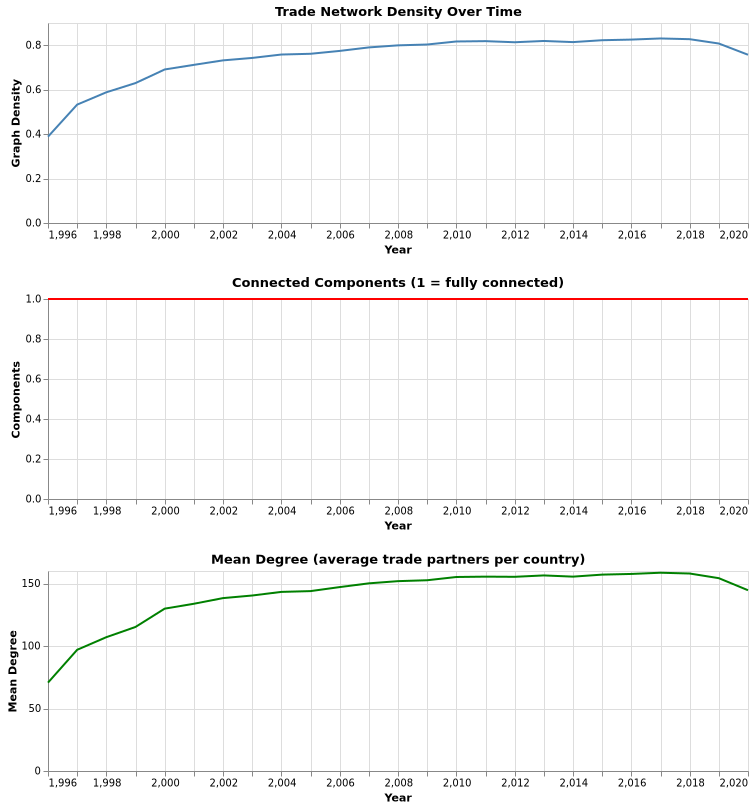

In [39]:
# Network evolution visualizations
p1 = network_stats |> @vlplot(width=700, height=200,
    title="Trade Network Density Over Time",
    mark={:line, strokeWidth=2, color="steelblue"},
    x={field=:year, type=:quantitative, title="Year"},
    y={field=:density, type=:quantitative, title="Graph Density"})

p2 = network_stats |> @vlplot(width=700, height=200,
    title="Connected Components (1 = fully connected)",
    mark={:line, strokeWidth=2, color="red"},
    x={field=:year, type=:quantitative, title="Year"},
    y={field=:n_components, type=:quantitative, title="Components"})

p3 = network_stats |> @vlplot(width=700, height=200,
    title="Mean Degree (average trade partners per country)",
    mark={:line, strokeWidth=2, color="green"},
    x={field=:year, type=:quantitative, title="Year"},
    y={field=:mean_degree, type=:quantitative, title="Mean Degree"})

[p1; p2; p3]

## 5. Degree Distribution and Trade Concentration (2019)

In [40]:
# 2019 snapshot — degree distribution and top/bottom countries
yr2019 = filter(r -> r.year == 2019 && !ismissing(r.tradeflow_baci) && r.tradeflow_baci > 0 &&
                     !ismissing(r.iso3_o) && !ismissing(r.iso3_d) &&
                     r.iso3_o in qog_matched && r.iso3_d in qog_matched &&
                     r.iso3_o != r.iso3_d, grav)

countries_2019 = sort(unique(vcat(yr2019.iso3_o, yr2019.iso3_d)))
idx_2019 = Dict(c => i for (i, c) in enumerate(countries_2019))
g2019 = SimpleGraph(length(countries_2019))
for r in eachrow(yr2019)
    add_edge!(g2019, idx_2019[r.iso3_o], idx_2019[r.iso3_d])
end

degs_2019 = degree(g2019)
deg_df = DataFrame(iso3=countries_2019, degree=degs_2019)
sort!(deg_df, :degree, rev=true)

println("2019: $(nv(g2019)) nodes, $(ne(g2019)) edges, density=$(round(2*ne(g2019)/(nv(g2019)*(nv(g2019)-1)), digits=3))")
println("\nTop 15:"); println(first(deg_df, 15))
println("\nBottom 15:"); println(last(deg_df, 15))

2019: 192 nodes, 14809 edges, density=0.808

Top 15:
15×2 DataFrame
 Row │ iso3    degree 
     │ String  Int64  
─────┼────────────────
   1 │ AUT        191
   2 │ BEL        191
   3 │ BRA        191
   4 │ CHN        191
   5 │ CZE        191
   6 │ DEU        191
   7 │ ESP        191
   8 │ GBR        191
   9 │ IDN        191
  10 │ IND        191
  11 │ ITA        191
  12 │ NLD        191
  13 │ POL        191
  14 │ SVK        191
  15 │ SWE        191

Bottom 15:
15×2 DataFrame
 Row │ iso3    degree 
     │ String  Int64  
─────┼────────────────
   1 │ KNA         92
   2 │ WSM         91
   3 │ MHL         90
   4 │ BTN         84
   5 │ TLS         82
   6 │ GNB         81
   7 │ NRU         81
   8 │ VUT         81
   9 │ SLB         75
  10 │ TON         67
  11 │ TUV         65
  12 │ PLW         60
  13 │ KIR         57
  14 │ SSD         56
  15 │ FSM         55


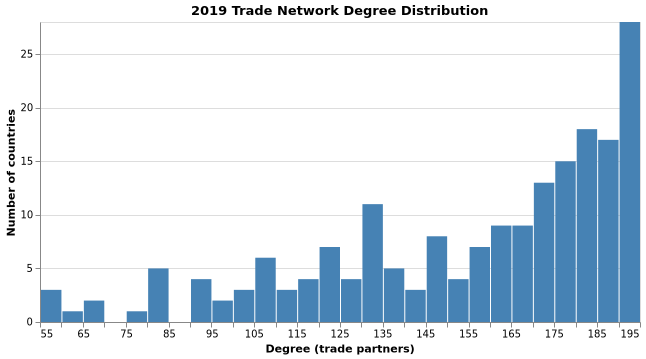

In [41]:
# Degree distribution — is it power-law-like?
deg_df |> @vlplot(
    width=600, height=300,
    title="2019 Trade Network Degree Distribution",
    mark={:bar, color="steelblue"},
    x={field=:degree, type=:quantitative, bin={step=5}, title="Degree (trade partners)"},
    y={"count()", title="Number of countries"}
)

In [43]:
# Weighted degree — total trade volume per country (2019, BACI)
weighted = combine(groupby(yr2019, :iso3_o),
    :tradeflow_baci => sum => :total_exports,
    :tradeflow_baci => mean => :avg_per_partner,
    nrow => :n_partners
)
sort!(weighted, :total_exports, rev=true)
println("Top 15 by total export volume (2019, BACI, thousands USD):")
first(weighted, 15)

Top 15 by total export volume (2019, BACI, thousands USD):


Row,iso3_o,total_exports,avg_per_partner,n_partners
,String,Float64,Float64,Int64
1,CHN,2.33685e9,1.22348e7,191
2,USA,1.48359e9,7.80834e6,190
3,DEU,1.41611e9,7.41421e6,191
4,JPN,6.62333e8,3.50441e6,189
5,FRA,5.46912e8,2.90911e6,188
6,NLD,5.26233e8,2.76964e6,190
7,KOR,5.23393e8,2.7547e6,190
8,ITA,5.11997e8,2.68061e6,191
9,MEX,4.73338e8,3.0538e6,155


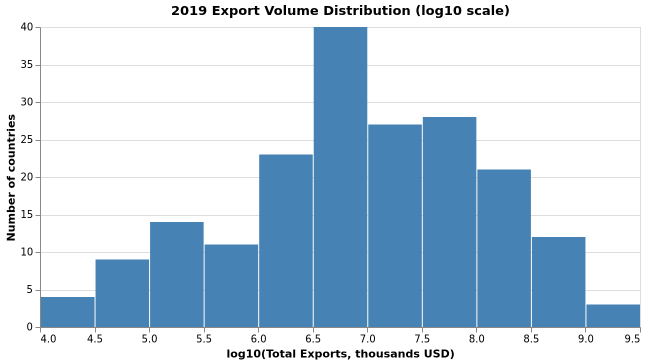

In [47]:
weighted[!, :log_exports] = log10.(weighted.total_exports_k)

weighted |> @vlplot(
    width=600, height=300,
    title="2019 Export Volume Distribution (log10 scale)",
    mark={:bar, color="steelblue"},
    x={field=:log_exports, type=:quantitative, bin={step=0.5}, title="log10(Total Exports, thousands USD)"},
    y={"count()", title="Number of countries"}
)

In [48]:
# Trade concentration — top partner share
country_trade = combine(groupby(yr2019, :iso3_o),
    :tradeflow_baci => sum => :total_exports,
    :tradeflow_baci => maximum => :max_partner_exports,
    nrow => :n_partners
)
country_trade[!, :top_partner_share] = country_trade.max_partner_exports ./ country_trade.total_exports
sort!(country_trade, :top_partner_share, rev=true)

println("Most trade-dependent (highest top-partner share, 2019):")
first(select(country_trade, :iso3_o, :n_partners, :total_exports, :top_partner_share), 15)

Most trade-dependent (highest top-partner share, 2019):


Row,iso3_o,n_partners,total_exports,top_partner_share
,String,Int64,Float64,Float64
1,BTN,76,2.62841e5,0.898877
2,SSD,44,1.71727e6,0.879847
3,HTI,120,1.32695e6,0.816465
4,MNG,108,8.17003e6,0.807529
5,TKM,98,1.00434e7,0.765739
6,MEX,155,4.73338e8,0.750996
7,CAN,185,4.28947e8,0.732962
8,FSM,42,1.29422e5,0.729085
9,PLW,47,23572.4,0.714727


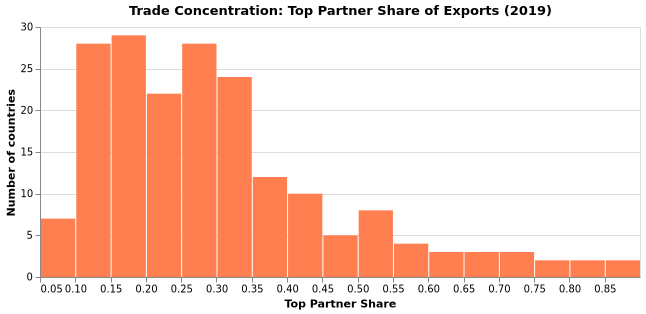

In [49]:
# Trade concentration histogram
country_trade |> @vlplot(
    width=600, height=250,
    title="Trade Concentration: Top Partner Share of Exports (2019)",
    mark={:bar, color="coral"},
    x={field=:top_partner_share, type=:quantitative, bin={step=0.05}, title="Top Partner Share"},
    y={"count()", title="Number of countries"}
)

In [51]:
# Identify WHO the top partner is for each country
top_partners = combine(groupby(yr2019, :iso3_o)) do sdf
    idx = argmax(sdf.tradeflow_baci)
    (top_partner=sdf.iso3_d[idx], top_flow=sdf.tradeflow_baci[idx])
end

# Join with concentration data
conc = innerjoin(country_trade, top_partners, on=:iso3_o)
sort!(conc, :top_partner_share, rev=true)
println("Most trade-dependent — WHO they depend on:")
first(select(conc, :iso3_o, :top_partner, :top_partner_share, :total_exports, :n_partners), 20)

Most trade-dependent — WHO they depend on:


Row,iso3_o,top_partner,top_partner_share,total_exports,n_partners
,String,String,Float64,Float64,Int64
1,BTN,IND,0.898877,2.62841e5,76
2,SSD,CHN,0.879847,1.71727e6,44
3,HTI,USA,0.816465,1.32695e6,120
4,MNG,CHN,0.807529,8.17003e6,108
5,TKM,CHN,0.765739,1.00434e7,98
6,MEX,USA,0.750996,4.73338e8,155
7,CAN,USA,0.732962,4.28947e8,185
8,FSM,THA,0.729085,1.29422e5,42
9,PLW,JPN,0.714727,23572.4,47


## 6. Temporal Stability — Edge Persistence

How much does the trade network rewire year-to-year? High Jaccard = stable edges. Low = volatile.

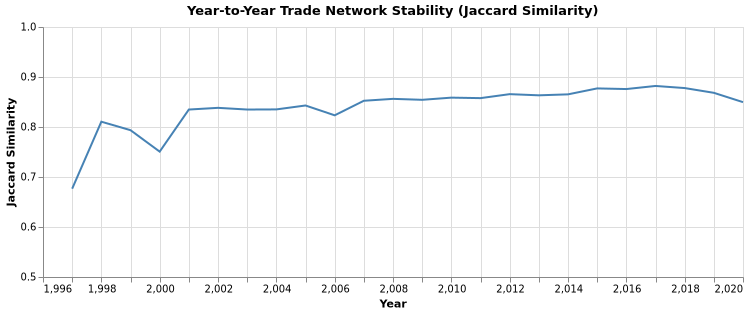

In [52]:
# Jaccard similarity of edge sets between consecutive years
function edge_set(df, yr)
    yr_data = filter(r -> r.year == yr && !ismissing(r.tradeflow_baci) && r.tradeflow_baci > 0 &&
                          !ismissing(r.iso3_o) && !ismissing(r.iso3_d), df)
    Set(Tuple(sort([r.iso3_o, r.iso3_d])) for r in eachrow(yr_data))
end

years_with_baci = sort(unique(filter(r -> !ismissing(r.tradeflow_baci) && r.tradeflow_baci > 0, grav).year))
jaccard_df = DataFrame(year=Int[], jaccard=Float64[], edges_added=Int[], edges_dropped=Int[])

prev_edges = nothing
for yr in years_with_baci
    curr_edges = edge_set(grav, yr)
    if prev_edges !== nothing && !isempty(prev_edges) && !isempty(curr_edges)
        j = length(intersect(prev_edges, curr_edges)) / length(union(prev_edges, curr_edges))
        push!(jaccard_df, (year=yr, jaccard=j,
              edges_added=length(setdiff(curr_edges, prev_edges)),
              edges_dropped=length(setdiff(prev_edges, curr_edges))))
    end
    prev_edges = curr_edges
end

jaccard_df |> @vlplot(
    width=700, height=250,
    title="Year-to-Year Trade Network Stability (Jaccard Similarity)",
    mark={:line, strokeWidth=2, color="steelblue"},
    x={field=:year, type=:quantitative, title="Year"},
    y={field=:jaccard, type=:quantitative, title="Jaccard Similarity", scale={domain=[0.5, 1.0]}}
)